In [1]:
! pip install --upgrade -q pandas numpy scikit-learn imbalanced-learn matplotlib

In [2]:
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import ConfusionMatrixDisplay

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE, SMOTENC
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline

from utils.constants import *

In [3]:
df = pd.read_csv("../data/3_gold/dataset-processed-gb.csv")

categorical_features = list(CATEGORICAL_COLUMNS)

for col in categorical_features:
    df[col] = LabelEncoder().fit_transform(df[col])

X = df.drop("class", axis=1)
y = df["class"]
y = y.map(TARGET_LABEL_MAP)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_RATIO, random_state=RANDOM_STATE, stratify=y
)

X_coarse = X_train.copy()
y_coarse = y_train.copy()
y_coarse = y_coarse.map(COARSE_LABEL_MAP)

high_risk_mask = y_train.isin([1, 2])
X_fine = X_train[high_risk_mask].copy()
y_fine = y_train[high_risk_mask].copy()
y_fine = y_fine.map(FINE_LABEL_MAP)

class_counts_coarse = Counter(y_coarse)
class_counts_fine = Counter(y_fine)

print("=== Coarse Data ===")
for class_idx, count in class_counts_coarse.items():
    print(f"Number of '{TARGET_NAMES_COARSE[class_idx]}' examples: {count}")

print("\n=== Fine Data ===")
for class_idx, count in class_counts_fine.items():
    print(f"Number of '{TARGET_NAMES_FINE[class_idx]}' examples: {count}")

=== Coarse Data ===
Number of 'low_risk' examples: 359256
Number of 'high_risk' examples: 252569

=== Fine Data ===
Number of 'alarm' examples: 228246
Number of 'severe' examples: 24323


In [ ]:
# smote_full = SMOTENC(categorical_features=categorical_features, random_state=RANDOM_STATE)

# X_train_resampled_full, y_train_resampled_full = smote_full.fit_resample(X_train, y_train)

# X_coarse_resampled_full = X_train_resampled_full.copy()
# y_coarse_resampled_full = y_train_resampled_full.copy()
# y_coarse_resampled_full = y_coarse_resampled_full.map(COARSE_LABEL_MAP)

# high_risk_mask = y_train_resampled_full.isin([1, 2])
# X_fine_resampled_full = X_train_resampled_full[high_risk_mask].copy()
# y_fine_resampled_full = y_train_resampled_full[high_risk_mask].copy()
# y_fine_resampled_full = y_fine_resampled_full.map(FINE_LABEL_MAP)

In [4]:
params_coarse = {
    'max_iter': 2000, 
    'early_stopping': True, 
    'max_depth': 6,
    'learning_rate': 0.05,
    'categorical_features': categorical_features,
    'class_weight': 'balanced',
    'random_state': RANDOM_STATE
}
params_fine = {
    'max_iter': 2000, 
    'early_stopping': True, 
    'max_depth': 8,
    'learning_rate': 0.03,
    'categorical_features': categorical_features,
    'class_weight': 'balanced',
    'random_state': RANDOM_STATE
}
params_multi = {
    'max_iter': 2000, 
    'early_stopping': True, 
    'max_depth': 8,
    'learning_rate': 0.03,
    'categorical_features': categorical_features,
    'class_weight': 'balanced',
    'random_state': RANDOM_STATE
}

In [5]:
def get_hgb_models():
    model_coarse = HistGradientBoostingClassifier(**params_coarse)
    model_fine = HistGradientBoostingClassifier(**params_fine)
    return model_coarse, model_fine


def resample_coarse(X, y):
    class_counts = Counter(y)
    under = RandomUnderSampler(sampling_strategy={0: class_counts[1]}, random_state=RANDOM_STATE)
    return under.fit_resample(X, y)


def resample_fine(X, y):
    class_counts = Counter(y)
    n_sample = max(class_counts[1], class_counts[0] // 2)
    pipeline = Pipeline([
        ('under', RandomUnderSampler(sampling_strategy={0: n_sample}, random_state=RANDOM_STATE)),
        ('over', SMOTENC(categorical_features=categorical_features, sampling_strategy={1: n_sample}, random_state=RANDOM_STATE))
    ])
    return pipeline.fit_resample(X, y)


def resample_multi(X, y):
    class_counts = Counter(y)
    n_low, n_alarm, n_severe = class_counts[0], class_counts[1], class_counts[2]
    pipeline = Pipeline([
        ('under', RandomUnderSampler(sampling_strategy={0: max(n_alarm, n_low // 2)}, random_state=RANDOM_STATE)),
        ('over', SMOTENC(categorical_features=categorical_features, sampling_strategy={2: max(n_severe, n_alarm // 2)}, random_state=RANDOM_STATE))
    ])
    return pipeline.fit_resample(X, y)


def train_multiclass_hgb(X, y):
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=TEST_RATIO, random_state=RANDOM_STATE, stratify=y
    )
    model = HistGradientBoostingClassifier(**params_multi)

    print("Training Multiclass Model...")
    model.fit(X_train, y_train, X_val=X_val, y_val=y_val)

    return model


def train_hierarchical_hgb(X_coarse, y_coarse, X_fine, y_fine, calibrate=False):
    X_train_coarse, X_val_coarse, y_train_coarse, y_val_coarse = train_test_split(
        X_coarse, y_coarse, test_size=TEST_RATIO, random_state=RANDOM_STATE, stratify=y_coarse
    )
    X_train_fine, X_val_fine, y_train_fine, y_val_fine = train_test_split(
        X_fine, y_fine, test_size=TEST_RATIO, random_state=RANDOM_STATE, stratify=y_fine
    )
    model_coarse, model_fine = get_hgb_models()

    print("Training Coarse Model...")
    model_coarse.fit(
        X_train_coarse, y_train_coarse,
        X_val=X_val_coarse, y_val=y_val_coarse
    )

    print("Training Fine Model...")
    model_fine.fit(
        X_train_fine, y_train_fine,
        X_val=X_val_fine, y_val=y_val_fine
    )

    if not calibrate:
        return model_coarse, model_fine

    calibrated_coarse = CalibratedClassifierCV(model_coarse, method='isotonic', cv='prefit')
    calibrated_fine = CalibratedClassifierCV(model_fine, method='isotonic', cv='prefit')

    calibrated_coarse.fit(X_val_coarse, y_val_coarse)
    calibrated_fine.fit(X_val_fine, y_val_fine)

    return calibrated_coarse, calibrated_fine


def predict_soft_cascade(model_coarse, model_fine, X, y, ):
    # Get Probabilities from Coarse
    probs_coarse = model_coarse.predict_proba(X)
    p_high_risk = probs_coarse[:, 1]
    
    # Get Probabilities from Fine
    probs_fine = model_fine.predict_proba(X) 
    p_severe_given_high = probs_fine[:, 1] # P(Severe | High)
        
    # P(Severe) = P(High) * P(Severe | High)
    p_severe_global = p_high_risk * p_severe_given_high
    
    # P(Alarm) = P(High) * (1 - P(Severe | High))
    p_alarm_global = p_high_risk * (1 - p_severe_given_high)
    
    # P(Low) = 1 - P(High)
    p_low_global = 1.0 - p_high_risk
    
    final_probs = np.vstack([p_low_global, p_alarm_global, p_severe_global]).T
    final_preds = np.argmax(final_probs, axis=1)

    print(classification_report(y, final_preds, target_names=["Low Risk", "Alarm", "Severe"]))
    return f1_score(y, final_preds, average='macro'), final_preds


def predict_hard_cascade(
    model_coarse, model_fine, X, y, 
    threshold_coarse=0.4, threshold_fine=0.5
):
    # Predict Coarse (0 = Low, 1 = High)
    probs_coarse = model_coarse.predict_proba(X)[:, 1]
    
    preds_coarse = (probs_coarse >= threshold_coarse).astype(int)
    final_preds = preds_coarse.copy()
    
    high_risk_indices = np.where(preds_coarse == 1)[0]
    
    if len(high_risk_indices) > 0:
        X_high_risk = X.iloc[high_risk_indices]
        
        # Predict Fine (0 = Alarm, 1 = Severe)
        probs_fine_local = model_fine.predict_proba(X_high_risk)[:, 1]
        preds_fine_local = (probs_fine_local >= threshold_fine).astype(int)
        
        # Map Fine predictions back to Global labels
        preds_fine_global = np.array([FINE_LABEL_MAP_REVERSE[p] for p in preds_fine_local])
        final_preds[high_risk_indices] = preds_fine_global

    print(classification_report(y, final_preds, target_names=["Low Risk", "Alarm", "Severe"]))
    return f1_score(y, final_preds, average='macro'), final_preds

In [6]:
model_coarse, model_fine = train_hierarchical_hgb(X_coarse, y_coarse, X_fine, y_fine)

Training Coarse Model...
Training Fine Model...


In [37]:
model_multi = train_multiclass_hgb(X_train, y_train)

Training Multiclass Model...


In [7]:
f1_soft, preds_soft = predict_soft_cascade(
    model_coarse, model_fine, X_test, y_test
)
f1_hard, preds_hard = predict_hard_cascade(
    model_coarse, model_fine, X_test, y_test,
    threshold_coarse=0.4, threshold_fine=0.5
)

              precision    recall  f1-score   support

    Low Risk       0.73      0.85      0.78     63399
       Alarm       0.66      0.34      0.45     40279
      Severe       0.16      0.47      0.24      4292

    accuracy                           0.65    107970
   macro avg       0.51      0.56      0.49    107970
weighted avg       0.68      0.65      0.64    107970

              precision    recall  f1-score   support

    Low Risk       0.80      0.62      0.70     63399
       Alarm       0.52      0.53      0.53     40279
      Severe       0.14      0.54      0.22      4292

    accuracy                           0.59    107970
   macro avg       0.48      0.57      0.48    107970
weighted avg       0.67      0.59      0.62    107970



In [39]:
preds_multi = model_multi.predict(X_test)
print(classification_report(y_test, preds_multi, target_names=["Low Risk", "Alarm", "Severe"]))
f1_multi = f1_score(y_test, preds_multi, average='macro')

              precision    recall  f1-score   support

    Low Risk       0.83      0.75      0.79     63414
       Alarm       0.64      0.56      0.59     40283
      Severe       0.16      0.55      0.24      4294

    accuracy                           0.67    107991
   macro avg       0.54      0.62      0.54    107991
weighted avg       0.73      0.67      0.69    107991



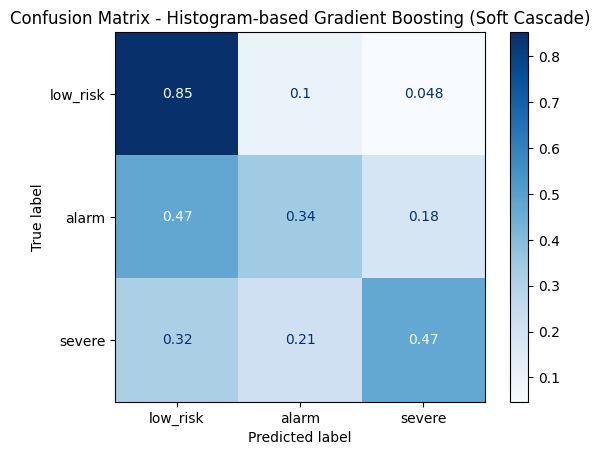

In [8]:
ConfusionMatrixDisplay.from_predictions(
    y_test, preds_soft, display_labels=TARGET_NAMES, cmap=plt.cm.Blues, normalize='true'
)
plt.title("Confusion Matrix - Histogram-based Gradient Boosting (Soft Cascade)")
plt.show()

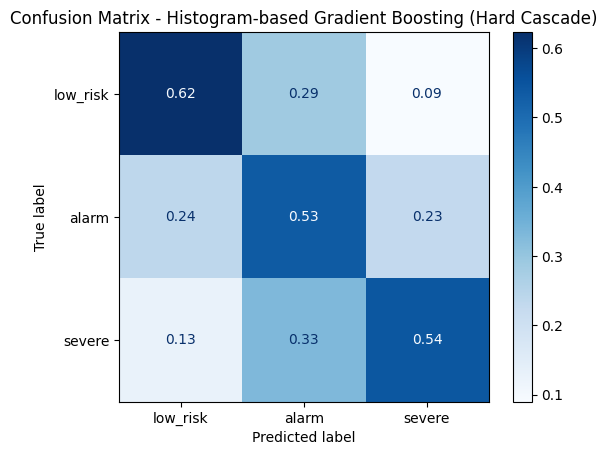

In [9]:
ConfusionMatrixDisplay.from_predictions(
    y_test, preds_hard, display_labels=TARGET_NAMES, cmap=plt.cm.Blues, normalize='true'
)
plt.title("Confusion Matrix - Histogram-based Gradient Boosting (Hard Cascade)")
plt.show()

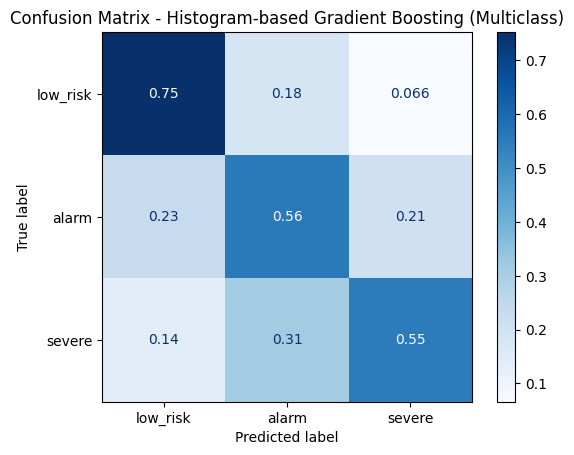

In [42]:
ConfusionMatrixDisplay.from_predictions(
    y_test, preds_multi, display_labels=TARGET_NAMES, cmap=plt.cm.Blues, normalize='true'
)
plt.title("Confusion Matrix - Histogram-based Gradient Boosting (Multiclass)")
plt.show()

In [43]:
_, X_val_coarse, _, y_val_coarse = train_test_split(
    X_coarse, y_coarse, test_size=TEST_RATIO, random_state=RANDOM_STATE, stratify=y_coarse
)
_, X_val_fine, _, y_val_fine = train_test_split(
    X_fine, y_fine, test_size=TEST_RATIO, random_state=RANDOM_STATE, stratify=y_fine
)

X_val_fine_resampled, y_val_fine_resampled = resample_fine(X_val_fine, y_val_fine)

calibrated_coarse = CalibratedClassifierCV(model_coarse, method='isotonic', cv='prefit')
calibrated_fine = CalibratedClassifierCV(model_fine, method='isotonic', cv='prefit')

calibrated_coarse.fit(X_val_coarse, y_val_coarse)
calibrated_fine.fit(X_val_fine_resampled, y_val_fine_resampled)

/home/gabriel/Documents/UFRGS/dengue-severity-prediction/.venv/lib/python3.10/site-packages/sklearn/calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
/home/gabriel/Documents/UFRGS/dengue-severity-prediction/.venv/lib/python3.10/site-packages/sklearn/calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


,estimator,HistGradientB...ndom_state=42)
,method,'isotonic'
,cv,'prefit'
,n_jobs,None
,ensemble,'auto'
,loss,'log_loss'
,learning_rate,0.03
,max_iter,2000
,max_leaf_nodes,31
,max_depth,9
,min_samples_leaf,20


In [44]:
f1_soft_calibrated, preds_soft_calibrated = predict_soft_cascade(
    calibrated_coarse, calibrated_fine, X_test, y_test,
)
f1_hard_calibrated, preds_hard_calibrated = predict_hard_cascade(
    calibrated_coarse, calibrated_fine, X_test, y_test,
    threshold_coarse=0.4, threshold_fine=0.5
)

              precision    recall  f1-score   support

    Low Risk       0.75      0.90      0.82     63414
       Alarm       0.75      0.43      0.55     40283
      Severe       0.22      0.41      0.28      4294

    accuracy                           0.71    107991
   macro avg       0.57      0.58      0.55    107991
weighted avg       0.73      0.71      0.70    107991

              precision    recall  f1-score   support

    Low Risk       0.83      0.75      0.79     63414
       Alarm       0.63      0.61      0.62     40283
      Severe       0.18      0.48      0.27      4294

    accuracy                           0.69    107991
   macro avg       0.55      0.61      0.56    107991
weighted avg       0.73      0.69      0.70    107991



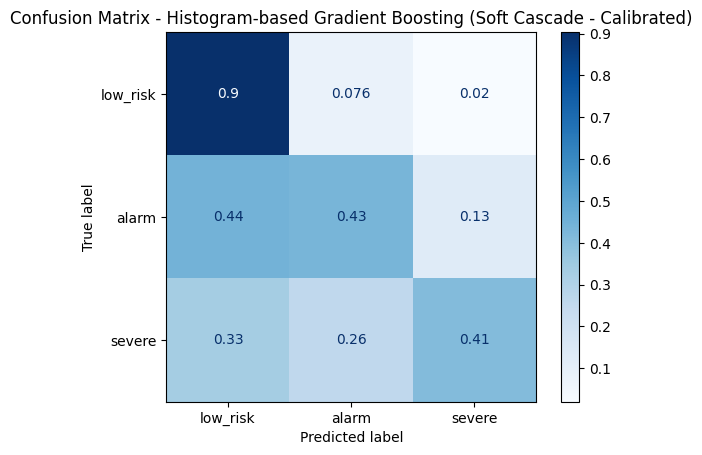

In [45]:
ConfusionMatrixDisplay.from_predictions(
    y_test, preds_soft_calibrated, display_labels=TARGET_NAMES, cmap=plt.cm.Blues, normalize='true'
)
plt.title("Confusion Matrix - Histogram-based Gradient Boosting (Soft Cascade - Calibrated)")
plt.show()

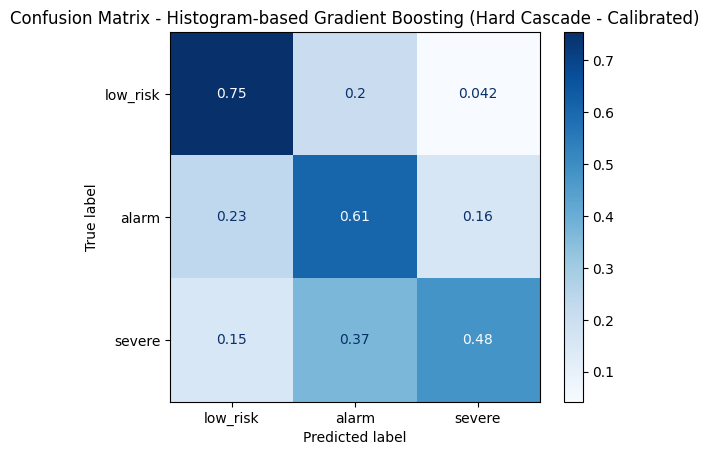

In [46]:
ConfusionMatrixDisplay.from_predictions(
    y_test, preds_hard_calibrated, display_labels=TARGET_NAMES, cmap=plt.cm.Blues, normalize='true'
)
plt.title("Confusion Matrix - Histogram-based Gradient Boosting (Hard Cascade - Calibrated)")
plt.show()

In [47]:
_, X_val, _, y_val = train_test_split(
    X_train, y_train, test_size=TEST_RATIO, random_state=RANDOM_STATE, stratify=y_train
)

X_val_resampled, y_val_resampled = resample_multi(X_val, y_val)

calibrated_multi = CalibratedClassifierCV(model_multi, method='isotonic', cv='prefit')
calibrated_multi.fit(X_val_resampled, y_val_resampled)

/home/gabriel/Documents/UFRGS/dengue-severity-prediction/.venv/lib/python3.10/site-packages/sklearn/calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


,estimator,HistGradientB...ndom_state=42)
,method,'isotonic'
,cv,'prefit'
,n_jobs,None
,ensemble,'auto'
,loss,'log_loss'
,learning_rate,0.03
,max_iter,2000
,max_leaf_nodes,31
,max_depth,9
,min_samples_leaf,20


In [48]:
preds_multi_calibrated = calibrated_multi.predict(X_test)
print(classification_report(y_test, preds_multi_calibrated, target_names=["Low Risk", "Alarm", "Severe"]))
f1_calibrated = f1_score(y_test, preds_multi_calibrated, average='macro')

              precision    recall  f1-score   support

    Low Risk       0.82      0.77      0.79     63414
       Alarm       0.63      0.69      0.66     40283
      Severe       0.27      0.31      0.29      4294

    accuracy                           0.72    107991
   macro avg       0.57      0.59      0.58    107991
weighted avg       0.73      0.72      0.72    107991



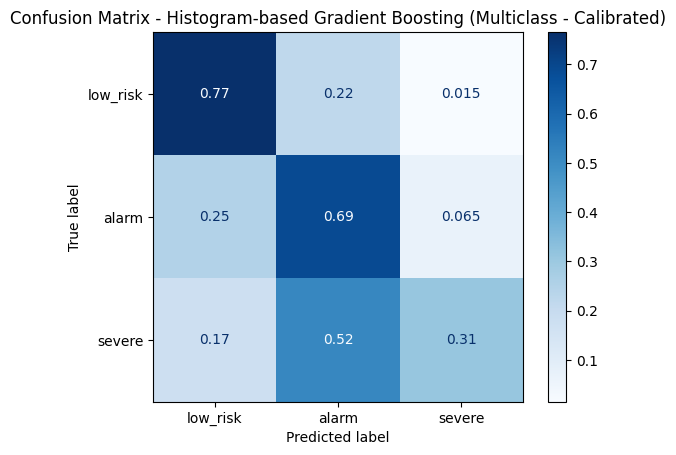

In [49]:
ConfusionMatrixDisplay.from_predictions(
    y_test, preds_multi_calibrated, display_labels=TARGET_NAMES, cmap=plt.cm.Blues, normalize='true'
)
plt.title("Confusion Matrix - Histogram-based Gradient Boosting (Multiclass - Calibrated)")
plt.show()

In [ ]:
# params_coarse_resample = {
#     'max_iter': 2000, 
#     'early_stopping': True, 
#     'max_depth': 6,
#     'learning_rate': 0.05,
#     'categorical_features': categorical_features,
#     'random_state': RANDOM_STATE
# }
# params_fine_resample = {
#     'max_iter': 2000, 
#     'early_stopping': True, 
#     'max_depth': 8,
#     'learning_rate': 0.03,
#     'categorical_features': categorical_features,
#     'random_state': RANDOM_STATE
# }

In [ ]:
# def train_hierarchical_hgb_resample(X_coarse, y_coarse, X_fine, y_fine):
#     X_train_coarse, X_val_coarse, y_train_coarse, y_val_coarse = train_test_split(
#         X_coarse, y_coarse, test_size=TEST_RATIO, random_state=RANDOM_STATE, stratify=y_coarse
#     )
#     X_train_fine, X_val_fine, y_train_fine, y_val_fine = train_test_split(
#         X_fine, y_fine, test_size=TEST_RATIO, random_state=RANDOM_STATE, stratify=y_fine
#     )
#     model_coarse, model_fine = get_hgb_models()

#     X_train_coarse_resampled, y_train_coarse_resampled = resample_coarse(X_train_coarse, y_train_coarse)

#     print("Training Coarse Model...")
#     model_coarse.fit(
#         X_train_coarse_resampled, y_train_coarse_resampled,
#         X_val=X_val_coarse, y_val=y_val_coarse
#     )

#     X_train_fine_resampled, y_train_fine_resampled = resample_fine(X_train_fine, y_train_fine)

#     print("Training Fine Model...")
#     model_fine.fit(
#         X_train_fine_resampled, y_train_fine_resampled,
#         X_val=X_val_fine, y_val=y_val_fine
#     )
#     return model_coarse, model_fine

In [ ]:
# model_coarse_resample, model_fine_resample = train_hierarchical_hgb(X_coarse_resampled_full, y_coarse_resampled_full, X_fine_resampled_full, y_fine_resampled_full)

Training Coarse Model...
Training Fine Model...


In [ ]:
# f1_soft_resample, preds_soft_resample = predict_soft_cascade(
#     model_coarse_resample, model_fine_resample, X_test, y_test,
# )

              precision    recall  f1-score   support

    Low Risk       0.76      0.88      0.81     63414
       Alarm       0.73      0.45      0.56     40283
      Severe       0.16      0.36      0.22      4294

    accuracy                           0.70    107991
   macro avg       0.55      0.56      0.53    107991
weighted avg       0.72      0.70      0.70    107991



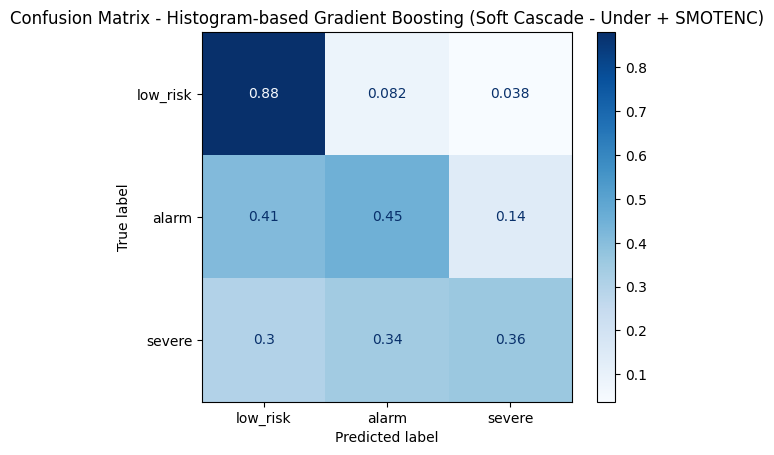

In [ ]:
# ConfusionMatrixDisplay.from_predictions(
#     y_test, preds_soft_resample, display_labels=TARGET_NAMES, cmap=plt.cm.Blues, normalize='true'
# )
# plt.title("Confusion Matrix - Histogram-based Gradient Boosting (Soft Cascade - Under + SMOTENC)")
# plt.show()

In [ ]:
# # Ordinal Decomposition Method
# # Model 1 -> 0: Low Risk, 1: Alarm or Severe
# # Model 2 -> 0: Low Risk or Alarm, 1: Severe

# M1_LABEL_MAP = {0: 0, 1: 1, 2: 1}
# M2_LABEL_MAP = {0: 0, 1: 0, 2: 1}

# X1 = X_train.copy()
# y1 = y_train.copy()
# y1 = y1.map(M1_LABEL_MAP)

# X2 = X_train.copy()
# y2 = y_train.copy()
# y2 = y2.map(M2_LABEL_MAP)

# class_counts_m1 = Counter(y1)
# class_counts_m2 = Counter(y2)

In [ ]:
# params1 = {
#     'max_iter': 2000, 
#     'early_stopping': True, 
#     'max_depth': 8,
#     'learning_rate': 0.03,
#     'categorical_features': categorical_features,
#     'class_weight': 'balanced',
#     'random_state': RANDOM_STATE
# }
# params2 = {
#     'max_iter': 2000, 
#     'early_stopping': True, 
#     'max_depth': 8,
#     'learning_rate': 0.03,
#     'categorical_features': categorical_features,
#     'class_weight': 'balanced',
#     'random_state': RANDOM_STATE
# }

In [ ]:
# def get_hgb_models_cumulative():
#     model1 = HistGradientBoostingClassifier(**params1)
#     model2 = HistGradientBoostingClassifier(**params2)
#     return model1, model2

In [ ]:
# def predict_cumulative(model1, model2, X, y):
#     p1 = model1.predict_proba(X)
#     p2 = model2.predict_proba(X)

#     p_high = p1[:, 1]            # P(High)   = P(M1 = 1)
#     p_low = 1.0 - p_high         # P(Low)    = 1 - P(High)
#     p_severe = p2[:, 1]          # P(Severe) = P(M2 = 1)
#     p_alarm = p_high - p_severe  # P(Alarm)  = P(High) - P(Severe)

#     p_alarm = p_alarm.clip(0.0, 1.0)
    
#     final_probs = np.vstack([p_low, p_alarm, p_severe]).T
#     final_preds = np.argmax(final_probs, axis=1)

#     print(classification_report(y, final_preds, target_names=["Low Risk", "Alarm", "Severe"]))
#     return f1_score(y, final_preds, average='macro'), final_preds


In [ ]:
# model1, model2 = train_hierarchical_hgb(X1, y1, X2, y2)

In [ ]:
# f1_cumulative, preds_cumulative = predict_cumulative(model1, model2, X_test, y_test)

              precision    recall  f1-score   support

    Low Risk       0.78      0.86      0.82     63414
       Alarm       0.68      0.64      0.66     40283
      Severe       0.52      0.03      0.06      4294

    accuracy                           0.74    107991
   macro avg       0.66      0.51      0.51    107991
weighted avg       0.73      0.74      0.73    107991



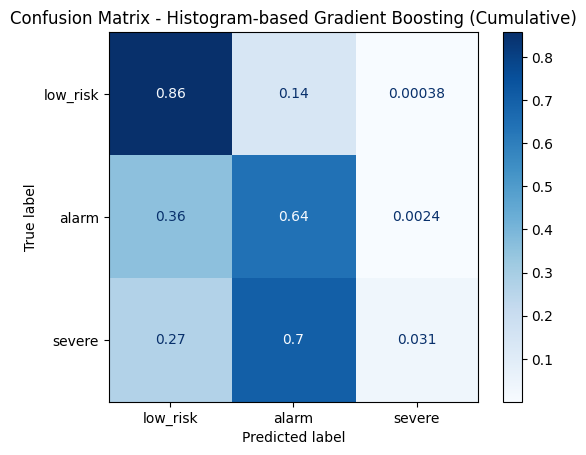

In [ ]:
# ConfusionMatrixDisplay.from_predictions(
#     y_test, preds_cumulative, display_labels=TARGET_NAMES, cmap=plt.cm.Blues, normalize='true'
# )
# plt.title("Confusion Matrix - Histogram-based Gradient Boosting (Cumulative)")
# plt.show()